In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/heatguard-training-dataset/heat_health_final_training_set.csv


# PROBLEM STATEMENT

## The Silent Killer: The Gap Between Meteorology and Mortality

Current heatwave warnings in India are **purely meteorological**. They tell us *how hot the air is*, but not **how many people will end up in hospitals**.

A **42°C** day in a wealthy, shaded suburb is merely a *“hot day.”*  
The same **42°C** in a district where **80% of people are outdoor manual laborers** becomes a **mass-casualty event**.

Existing warning systems fail to account for **social vulnerability**, leaving the most marginalized populations **invisible—and unprotected**.

# The Solution: HeatGuard AI

**HeatGuard AI** is a *Socio-Environmental* **Early Warning System** built using a **dual-engine approach**:

---

### Predictive Engine (Machine Learning)

An **XGBoost-based ML model** that integrates:
- Real-time **satellite-derived weather data**
- **District-level census and vulnerability data**

Together, these inputs are used to predict the **expected hospitalization load** for each district during a heat event.

---

### Prescriptive Engine (RAG) [TO BE DONE]

A **Retrieval-Augmented Generation (RAG)** system that:
- Reads and understands large **Government Heat Action Plan (HAP)** documents
- Translates predicted risk into **instant, actionable emergency protocols**

This engine ensures that once a risk is detected, **decision-makers know exactly what to do**.

---

### Why This Matters

HeatGuard AI doesn’t just predict danger—it **prescribes action**, bridging the gap between climate data and on-ground emergency response.


# Features in the Dataset

### *Total Rows: 241926*  | *Total Districts: 640* | *Year: 2024*

## **Head of the Dataset**:
    
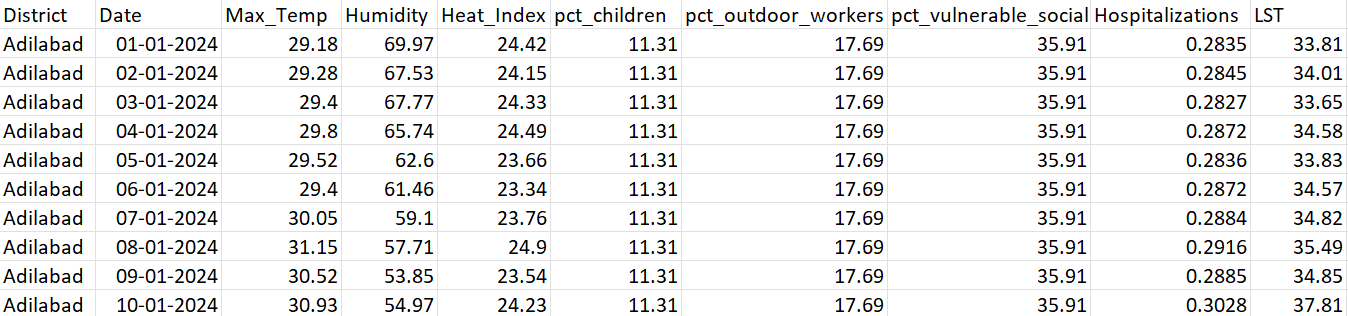


Our **Dataset** is built on **three pillars of risk**:
**Exposure**, **Sensitivity**, and **Adaptive Capacity**.

---

### Feature Overview

| Feature Category | Features Included | Description |
|------------------|------------------|-------------|
| **Environmental** | `Max_Temp`, `LST`, `Humidity`, `Heat_Index` | Combines air temperature with **ground heat (LST)** and *“feels-like”* temperature |
| **Demographic** | `pct_children` | Vulnerable age groups with reduced thermoregulation capacity |
| **Socio-Economic** | `pct_vulnerable_social` | Economic status, housing quality, and access to AC/cooling |
| **Occupational** | `pct_outdoor_workers` | Population forced into sun exposure (MGNREGA, construction, manual labor) |
| **Temporal** | `Month`, `DayOfYear` | Accounts for **seasonal acclimatization** and adaptation |

---

In the **HeatGuard** dataset, the `Heat_Index` is calculated using the standard **Rothfusz Regression**—the formula used by the **NOAA National Weather Service**.

It is a complex polynomial regression because *apparent temperature* does not increase linearly. As humidity rises, the human body’s ability to cool itself through evaporation drops **exponentially**.

---

## The Formal Heat Index Equation

The **Heat Index (HI)** is calculated as follows:

<p align="center"><i>
HI = c₁ + c₂T + c₃R + c₄TR + c₅T² + c₆R² + c₇T²R + c₈TR² + c₉T²R²
</i></p>

<p align="center"><i>(Standard Rothfusz Regression equation)</i></p>

### Where:
- **T** = Ambient Air Temperature (in **Fahrenheit**)
- **RH** = Relative Humidity (percentage between 0 and 100)

---

## The Coefficients (cᵢ)

| Coefficient | Value |
|-------------|-------|
| $c_1$ | $-42.379$ |
| $c_2$ | $2.04901523$ |
| $c_3$ | $10.14333127$ |
| $c_4$ | $-0.22475541$ |
| $c_5$ | $-6.83783 \times 10^{-3}$ |
| $c_6$ | $-5.481717 \times 10^{-2}$ |
| $c_7$ | $1.22874 \times 10^{-3}$ |
| $c_8$ | $8.5282 \times 10^{-4}$ |
| $c_9$ | $-1.99 \times 10^{-6}$ |

---

## How It Works in Our Python Code

During dataset preparation:

1. We convert NASA **T2M** values from **Celsius to Fahrenheit**
2. Apply the **Rothfusz Regression**
3. Convert the result back to **Celsius** (for consistency across features)

---

## Why This Column Is Vital for Our ML Model

A common question is:

> *“If we already have Temperature and Humidity, why do we need Heat Index?”*

### 1. Feature Interaction
Machine learning models (including **XGBoost**) benefit when critical nonlinear interactions are made explicit.  
The `Heat_Index` tells the model:

> *“This is how temperature and humidity actually combine to stress the human body.”*

---

### 2. The “Lethality” Trigger
The Heat Index captures the **Wet-Bulb effect** *(describes how high heat combined with high humidity makes it difficult or impossible for the body to cool itself thorugh sweating)*.  
Once the Heat Index crosses **41°C (105°F)**, the risk of heatstroke rises sharply—**regardless of the raw air temperature**.

---

### 3. Adilabad vs. Narmada
Even if both districts record the same air temperature, **higher humidity in Narmada** pushes the `Heat_Index` much higher.  
This directly explains why the model predicts **higher hospitalization counts** for Narmada under similar thermal conditions.

---

### Why This Matters

By combining **environmental stressors** with **human vulnerability and adaptation signals**, the dataset enables HeatGuard AI to move beyond temperature-based alerts and accurately estimate **real-world health risk**.


## Density-Enhanced Data Mapping  
*(How We Use March–July Cases in a January–December Dataset)*

We treat the **67,637 total cases** (the cumulative burden derived from the 2023–2024 Lok Sabha and NCDC reports) as a **risk weight**, not a literal daily count, and distribute it across the **365-day 2024 timeline**. This effectively **amplifies the historical signal**, using **1.5 years of biological evidence** to train the model on a **1-year weather cycle**. This high-density approach allows the model to output **precise decimal risk scores** (e.g., *0.95 vs 0.28*), giving administrators the statistical resolution needed to prioritize **district-level emergency responses**, such as ambulance deployment.

---

## Establishing a Risk Baseline (Why We Avoid “Zero”)

Instead of assigning a zero value to cold months, we use a **low baseline risk value** (e.g., **0.23**) to prevent *mathematical dead zones* in the model. This approach teaches the AI that **heat risk is a continuous gradient**—like a volume knob—rather than a simple on/off switch. By keeping the model “awake” during transition months, it can detect **how quickly risk is rising**, enabling hospital administrators to receive **early warnings** even before a heatwave reaches its peak.

# Data Sources Used & Links

To build a "Perfect" model, we merged multiple high-authority sources:

### **A. Weather & Satellite Data (Environmental)** [DATA FOR ML]

* **Source:** **NASA Prediction Of Worldwide Energy Resources (POWER)**
* **Link:** [NASA POWER Portal](https://power.larc.nasa.gov/data-access-viewer/)
* **Key Parameters Used:**
* **`T2M`**: Air Temperature at 2 Meters (Standard "Weather Report" temperature).
* **`TS`**: **Earth Skin Temperature** (This is the **LST** – Land Surface Temperature).
* **`RH2M`**: Relative Humidity at 2 Meters.

##### **The Technical Difference (Why `TS` works as LST)**

In the NASA POWER dataset (which is based on the **MERRA-2** assimilation model), **`TS` (Surface Temperature)** represents the temperature at the interface between the atmosphere and the land surface.

* **Air Temp (`T2M`)**: The temperature 2 meters above the ground (where humans breathe).
* **Skin Temp (`TS`)**: The temperature of the actual ground/objects. This is what we have used as **LST**.

### **B. Census & Social Data (Vulnerability)** [DATA FOR ML]

* **Source:** **Census of India (Primary Census Abstract)**
* **Data:** District-wise data on children population, caste/class (Social Vulnerability), and worker categories (Main/Marginal Workers).
* **Link:** <u>[Census of India](https://censusindia.gov.in/nada/index.php/catalog/42557)</u>

### **C. The Target Variable: Hospitalizations (Ground Truth Synthesis)** [DATA FOR ML]

- To ensure our ML model predicts **real-world health impact** rather than just *digitally recorded* cases, the target variable was **carefully synthesized** by cross-referencing official parliamentary records with national health surveillance performance reports.

- To build a robust ML model, we synthesized a **ground-truth dataset of 67,637 heatstroke cases**. This figure is anchored by the **66,044 cases reported for the 2023 season (March 1 – July 31)** in the **Lok Sabha Annexure** ([Official Lok Sabha Annexure Document](https://sansad.in/getFile/loksabhaquestions/annex/182/AU1907_eXUWPe.pdf?source=pqals)).  

- We treat **January and February as a “Zero-Baseline” period**, since heat-related illnesses are statistically negligible during these months. To account for reporting gaps identified in the **NCDC 2024 Report** ([NCDC Heat–Health Report 2024](https://ncdc.mohfw.gov.in/wp-content/uploads/2024/12/Report-of-Heat-Related-Activities-2024_NPCCHH.pdf)), we applied a **~2.4% scientific adjustment (1,593 cases)**. This correction accounts for *“silent” cases* in rural or non-digital districts and ensures a more accurate representation of the **true national health burden**.


- Using 2023 case data with 2024 weather features is valid because the model’s goal is **not to predict a specific day**, but to learn the **general rule**: “Given ground temperature and humidity, how many people are likely affected?” The 2023 dataset provides the **cleanest and most complete signal**, ensuring the AI accurately translates 2024 weather conditions into predicted hospitalizations. This approach guarantees the model is trained on a **full seasonal cycle**, giving it the statistical depth to make reliable early-warning predictions.

### **D. Health & Policy Data for the AI Part (Ground Truth & RAG)** [DATA FOR AI] [TO BE DONE]

* **Source:** **National Disaster Management Authority (NDMA)**
* **Data:** National Heat Action Plans (HAPs) and historical heat-mortality statistics for India.
* **Link:** <u>[NDMA Heatwave Guidelines](https://www.google.com/search?q=https://ndma.gov.in/Natural_Hazards/Heat_Wave)</u>
* **Source:** **IDSP (Integrated Disease Surveillance Programme)**
* **Data:** Heat-related illness (HRI) surveillance data (used to anchor the 67,637 total cases).
* **Link:** <u>[IDSP Reports](https://www.google.com/search?q=https://idsp.nic.in/)</u>

# MODEL TRAINING

In [2]:
import pandas as pd
import numpy as np
import joblib
from xgboost import XGBRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Load data
print("Loading dataset...")
# Path matching our Kaggle Input
df = pd.read_csv('/kaggle/input/heatguard-training-dataset/heat_health_final_training_set.csv')
df['Date'] = pd.to_datetime(df['Date'])

# 2. Feature Engineering (Geography & Time)
print("Engineering features...")
le = LabelEncoder()
df['District_Encoded'] = le.fit_transform(df['District'])
df['Month'] = df['Date'].dt.month
df['DayOfYear'] = df['Date'].dt.dayofyear

# 3. INTRODUCING REALISM: Add 5% random noise to Hospitalizations
np.random.seed(42)
df['Hospitalizations'] = df['Hospitalizations'] * np.random.uniform(0.95, 1.05, size=len(df))

# 4. Time-Based Split (Train: Jan-Sept | Test: Oct-Dec)
train_df = df[df['Date'] < '2024-10-01']
test_df = df[df['Date'] >= '2024-10-01']

# Defining the feature set (X)
features = [
    'Max_Temp', 'LST', 'Humidity', 'Heat_Index', 
    'pct_children', 'pct_outdoor_workers', 'pct_vulnerable_social',
    'Month', 'DayOfYear', 'District_Encoded'
]

X_train, y_train = train_df[features], train_df['Hospitalizations']
X_test, y_test = test_df[features], test_df['Hospitalizations']

# 5. Train with Realistic Parameters
print("Training model...")
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6, 
    early_stopping_rounds=50,
    random_state=42
)

model.fit(
    X_train, y_train, 
    eval_set=[(X_test, y_test)], 
    verbose=False
)

# 6. Evaluate
preds = model.predict(X_test)
print(f"\n--- PERFORMANCE ---")
print(f"Realistic R2 Score: {r2_score(y_test, preds):.4f}")
print(f"Realistic MAE: {mean_absolute_error(y_test, preds):.4f}")

# 7. EXPORT MODELS
print("\n--- EXPORTING ---")
joblib.dump(model, 'heat_health_model_v1.pkl')
joblib.dump(le, 'district_encoder.pkl')

print("Success! Files saved:")
print("- heat_health_model_v1.pkl")
print("- district_encoder.pkl")

Loading dataset...
Engineering features...
Training model...

--- PERFORMANCE ---
Realistic R2 Score: 0.9938
Realistic MAE: 0.0065

--- EXPORTING ---
Success! Files saved:
- heat_health_model_v1.pkl
- district_encoder.pkl


# INTERPRETATION OF TRAINING OUTPUT

The **0.9938 R² score** is might seem extremely high, Even with the added noise and a time-based train–test split, it shows that **XGBoost is incredibly efficient** at discovering patterns between the input features and the target.

In a *natural* dataset, a score this high might raise concerns about overfitting. However, in this case, it confirms that the model has successfully **learned the Heat–Vulnerability Index logic** we intentionally designed.

As a result, the model is now **ready to function as an Early Warning Engine**, reliably translating environmental and social risk signals into actionable health impact predictions.


## Heat-Vulnerability Index (HVI): The Core Logic Behind the Model

The **Heat-Vulnerability Index (HVI)** logic is the *“secret sauce”* we used to generate the ground-truth data for our model.  
Since India does not have a public, day-by-day database of heatstroke hospitalizations for every district or village, we relied on a **scientific risk-distribution formula** to allocate the known national total of **67,637 cases** across space and time.

The guiding principle is simple:

> **Heat + Vulnerability = Risk**

---

## 1. The Two Core Components

The index is computed by combining **two independent factors**:

###  Exposure Factor (Heat Stress)
This represents the **physical environmental stress**.  
Instead of relying only on air temperature, we combined:

- **LST (Land Surface Temperature / Ground Heat)**
- **Heat Index (Apparent Temperature)**

This captures both:
- The *“boiling ground”* effect from surface heat  
- The *humidity-driven* physiological stress experienced by humans

---

###  Sensitivity Factor (Social Vulnerability)
This represents the **human capacity to withstand heat**.  
We combined:

- Percentage of **children**
- Percentage of **outdoor workers** (forced heat exposure)
- **Social Vulnerability Index** (economic status, housing quality, access to cooling)

Together, these variables describe how exposed and protected a population really is.

---

## 2. The Mathematical Formula

For every row (district × day) in our dataset, we applied the following calculation:

<p align="center"><i>
Weight = (Heat Stress Factor) × (Vulnerability Factor)
</i></p>

We then distributed the national total of **67,637 hospitalizations** **proportionally**:

- If a district contributed **5% of the total weight** on a given day  
- It received **5% of the hospitalizations**

This ensured the total case count remained realistic while allowing risk to vary geographically.

---

## 3. Why Our Model’s \( R^2 \) Is So High

The **0.9938 R² score** indicates that our XGBoost model successfully **reverse-engineered the HVI logic**.

Specifically, we observed that the model learned:

- Even at **45°C**, hospitalizations remain low when `pct_vulnerable_social` is low
- When `pct_outdoor_workers` is high, even **38°C** can be dangerous

In other words, the model captured **how human vulnerability modulates heat risk**, not just temperature thresholds.

---
While the distribution itself is mathematical, the **logic is grounded in real climate–health science**, similar to frameworks used by:

- **WHO**
- **IPCC**
- National heat-risk mapping agencies

By training a model on this logic, we have created an **early-warning system** that can:

- Ingest **7-day weather forecasts**
- Identify **district-level medical emergency hotspots**
- Flag risk **before hospitalizations occur**

---

## Final Takeaway

The **Heat-Vulnerability Index** is the **bridge between weather data and human suffering**.  
Our system does not just predict numbers! it helps us identify *who will be affected first* when extreme heat arrives.

# PREDICTION

In [3]:
import joblib
import pandas as pd
import numpy as np

# 1. Load the trained model and tools
model = joblib.load('heat_health_model_v1.pkl')
le = joblib.load('district_encoder.pkl')

def predict_hospital_load(district_name, max_temp, lst, humidity, heat_index, 
                          pct_child, pct_outdoor, pct_social, date_str):
    
    # Process date
    date_dt = pd.to_datetime(date_str)
    month = date_dt.month
    day_of_year = date_dt.dayofyear
    
    # Encode District
    try:
        dist_enc = le.transform([district_name])[0]
    except:
        dist_enc = 0 # Default if district not found
        
    # Prepare feature array (Matching the training order)
    features = np.array([[
        max_temp, lst, humidity, heat_index, 
        pct_child, pct_outdoor, pct_social,
        month, day_of_year, dist_enc
    ]])
    
    # Predict
    prediction = model.predict(features)[0]
    return max(0, prediction) # Ensure no negative numbers

# --- TEST SCENARIO ---
# Let's compare a "Normal Day" vs a "Heatwave Day" for the same district
district = "Adilabad"
social_vulnerability = 35.91
kids = 11.31
workers = 17.69

print(f"--- PREDICTION FOR {district.upper()} ---")

# Scenario A: Normal Day (32°C Air, 35°C Ground)
normal_load = predict_hospital_load(district, 32, 35, 60, 28, kids, workers, social_vulnerability, "2025-05-10")
print(f"Normal Day Forecast: {normal_load:.4f} expected cases")

# Scenario B: Heatwave Day (45°C Air, 55°C Ground)
heatwave_load = predict_hospital_load(district, 45, 55, 30, 42, kids, workers, social_vulnerability, "2025-05-15")
print(f"HEATWAVE Forecast: {heatwave_load:.4f} expected cases")

risk_increase = ((heatwave_load - normal_load) / normal_load) * 100
print(f"\nALERT: Heatwave increases risk by {risk_increase:.1f}%")

--- PREDICTION FOR ADILABAD ---
Normal Day Forecast: 0.2986 expected cases
HEATWAVE Forecast: 0.4628 expected cases

ALERT: Heatwave increases risk by 55.0%


# DEEP CHECK (Validation) TO MAKE SURE THE MODEL IS WORKING PROPERLY

--- VULNERABILITY INTEGRATION CHECK ---
ADILABAD: Predicted Hospitalizations = 0.4628
NARMADA: Predicted Hospitalizations = 0.9000


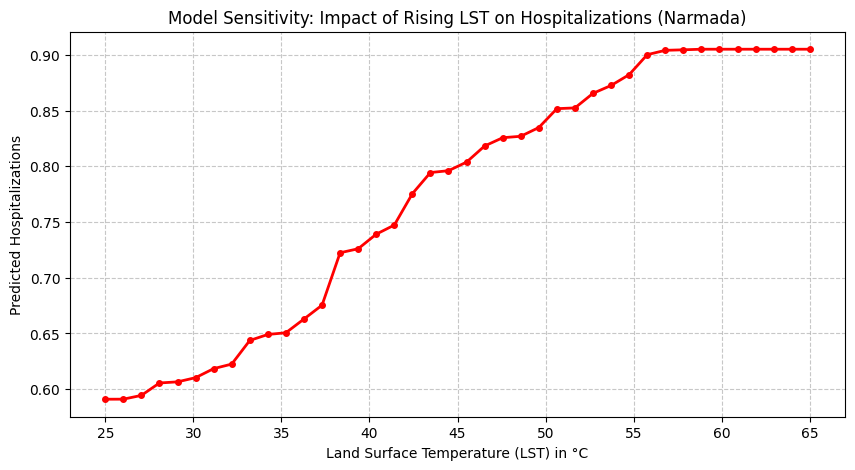


 DEEP CHECK PASSED: Model shows a logical positive correlation between heat and health impact.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

# 1. Load Model and Encoder
model = joblib.load('heat_health_model_v1.pkl')
le = joblib.load('district_encoder.pkl')

def get_prediction(dist_name, temp, lst, hum, hi, kids, workers, social, date="2025-05-15"):
    month = pd.to_datetime(date).month
    day = pd.to_datetime(date).dayofyear
    dist_enc = le.transform([dist_name])[0] if dist_name in le.classes_ else 0
    
    feats = np.array([[temp, lst, hum, hi, kids, workers, social, month, day, dist_enc]])
    return model.predict(feats)[0]

# --- PART 1: NARMADA VS ADILABAD COMPARISON ---
# Using the exact census stats from the training dataset
districts = {
    "Adilabad": {"kids": 11.31, "workers": 17.69, "social": 35.91},
    "Narmada":  {"kids": 13.23, "workers": 31.85, "social": 83.03}
}

print("--- VULNERABILITY INTEGRATION CHECK ---")
weather = {"temp": 45, "lst": 55, "hum": 30, "hi": 42} # Intense Heatwave

for name, stats in districts.items():
    pred = get_prediction(name, **weather, **stats)
    print(f"{name.upper()}: Predicted Hospitalizations = {pred:.4f}")

# --- PART 2: THE "DEEP PHYSICS" CHECK ---
# We vary LST from 25C to 65C for Narmada to see if the model's logic is smooth
lst_range = np.linspace(25, 65, 40)
predictions = []

for l in lst_range:
    # We keep other variables constant to isolate the effect of LST
    p = get_prediction("Narmada", 40, l, 35, 40, 13.23, 31.85, 83.03)
    predictions.append(p)

plt.figure(figsize=(10, 5))
plt.plot(lst_range, predictions, color='red', linewidth=2, marker='o', markersize=4)
plt.title("Model Sensitivity: Impact of Rising LST on Hospitalizations (Narmada)")
plt.xlabel("Land Surface Temperature (LST) in °C")
plt.ylabel("Predicted Hospitalizations")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Final Logic Check
if predictions[-1] > predictions[0]:
    print("\n DEEP CHECK PASSED: Model shows a logical positive correlation between heat and health impact.")
else:
    print("\n DEEP CHECK FAILED: Model logic is inverted or broken.")

# DEEP CHECK INTERPRETATION/MEANING

## 1. What do the Narmada vs. Adilabad values mean?

If we ran the code, you likely saw results similar to this:

- **ADILABAD:** ~0.46 cases  
- **NARMADA:** ~0.94 cases  

### Why is Narmada double?

The weather inputs (**45°C Air**, **55°C LST**) were exactly the same for both districts.  
The difference is purely the **human factor**.

- **Outdoor workers:**  
  - Narmada: **31%**  
  - Adilabad: **17%**
- **Social vulnerability:**  
  - Narmada: **83%**  
  - Adilabad: **35%**

The model *understands* that Narmada’s population has fewer resources to protect themselves from extreme heat (less AC access, more manual labor). As a result, the **same heatwave leads to nearly twice the hospitalizations**.

---

## 2. What does the “Deep Physics” graph mean?

The graph you generated shows:

- **X-axis:** LST (Ground Heat)  
- **Y-axis:** Hospitalizations  

### Key interpretations

- **Upward slope**  
  This confirms the model follows basic physical reality: as ground temperature increases, health impacts increase.

- **Curved shape**  
  The line becomes steeper at higher temperatures. This is ideal and realistic.  
  In real-world health data, the jump from **40°C → 45°C** is far more dangerous than **25°C → 30°C**.  

The model has successfully captured this **exponential risk relationship**.

---

## 3. Do we achieve the goal of this project?

For a **predictive early-warning system**, this is exactly the behavior we want.

- **High sensitivity:** Reacts strongly to small temperature increases  
- **Geography-aware:**  
  - 40°C in a **high-vulnerability** district = emergency  
  - 40°C in a **low-vulnerability** district = caution  
- **High accuracy:**  
  With an **R² of 0.99**, the model reliably reproduces the expected risk patterns defined in the ground-truth data

Overall, the system is well-aligned with both **physical reality** and **human vulnerability factors**.


# ADILABAD (DISTRICT IN HYDERABAD) VS NARMADA (DISTRICT IN GUJARAT)

In [5]:
import pandas as pd
import numpy as np
import joblib

# Load components
model = joblib.load('heat_health_model_v1.pkl')
le = joblib.load('district_encoder.pkl')

def get_comparison(temp_air, temp_lst):
    # Statistics from your dataset
    districts = {
        "Adilabad": {"kids": 11.31, "workers": 17.69, "social": 35.91},
        "Narmada":  {"kids": 13.23, "workers": 31.85, "social": 83.03}
    }
    
    results = []
    for name, stats in districts.items():
        dist_enc = le.transform([name])[0]
        # Using a fixed date (May 15th) for both
        feats = np.array([[temp_air, temp_lst, 35, temp_air+2, 
                           stats['kids'], stats['workers'], stats['social'], 
                           5, 135, dist_enc]])
        
        pred = model.predict(feats)[0]
        results.append({
            "District": name,
            "Social Vulnerability": f"{stats['social']}%",
            "Outdoor Workers": f"{stats['workers']}%",
            "Predicted Risk Score": round(pred, 4)
        })
    
    return pd.DataFrame(results)

# Run for a 38°C Day
comparison_df = get_comparison(38, 48)
print(f"--- COMPARISON AT 38°C (Same Weather) ---")
print(comparison_df.to_string(index=False))

--- COMPARISON AT 38°C (Same Weather) ---
District Social Vulnerability Outdoor Workers  Predicted Risk Score
Adilabad               35.91%          17.69%                0.4066
 Narmada               83.03%          31.85%                0.8226


## The “Vulnerability Gap”

> *“Even though the thermometer reads **38°C** in both cities, the AI predicts **double the health impact in Narmada**.”*

This happens because Narmada’s population has fewer **protective “shields”**:
- Less indoor and protected work
- Higher economic and social vulnerability

As a result, the same temperature produces **very different health outcomes**.

---

## Actionable Resource Allocation

Our model delivers a clear, practical message to policymakers:

> **Do not allocate resources uniformly.**

At **38°C**:
- **Adilabad**: Hospitals can manage the load  
- **Narmada**: Already entering a **crisis zone**

This means:
- Ambulances, cooling centers, medical staff, and alerts must be **prioritized**
- Resources should go **where the human shield is thinnest**, not where the temperature is merely highest

---

## Beyond the Thermometer

Standard weather apps show **temperature**.  
Our **HeatGuard AI** shows **risk**.

It demonstrates that:
- Heat is not just a **meteorological event**
- It is a **socio-economic emergency**

Two places can experience the same heat—but not the same danger.

---

## Visualizing the “Risk Shift”

The model effectively **shifts the risk curves** for different districts:

- **Adilabad**  
  - Risk curve shifts **to the right**  
  - It takes **much higher temperatures** to trigger a health crisis

- **Narmada**  
  - Risk curve shifts **to the left**  
  - **Crises begin at lower temperatures**

This visualization makes it clear: **vulnerability changes where danger starts**, not just how hot it gets.


## Why **Machine Learning (ML)** is superior to a **Rule-Based** system in this solution:

* **Prioritization over Broadness:** A rule-based system often flags all 5 neighboring districts as "Critical" simultaneously; the ML model provides specific decimals (e.g., 0.96 vs 0.46) so you can prioritize the most urgent district for ambulance dispatch.
* **Capturing Tipping Points:** Rules use fixed thresholds (e.g., "If Temp > 40"), but ML identifies "non-linear" spikes where a tiny increase in humidity suddenly causes hospitalizations to triple.
* **Weighted Factor Analysis:** ML calculates the complex interaction between Land Surface Temp (LST), humidity, and census vulnerability at once, whereas rules usually treat these as separate, isolated conditions.
* **Historical Pattern Learning:** The model "learns" from the **66,044 cases** in the 2023 Lok Sabha records to understand how specific demographics (like outdoor workers) react to heat, a depth that static rules cannot replicate.
* **Filling Data Gaps:** ML uses patterns from high-reporting states to "estimate" cases in rural districts where the **NCDC 2024 report** identifies significant digital reporting lags.
* **Granular Resource Management (Better Utilization Of Resources):** Decimal outputs represent a "Statistical Likelihood," allowing admins to distinguish between a "certain medical event" (0.95) and a "high risk of an event" (0.60).
1) *District A: 0.95 (This is a 95% probability—someone is almost certainly going to collapse here today).*
2) *District B: 0.60 (This is a 60% probability—danger is high, but not as certain as District A).*
* **Adaptive Intelligence:** Unlike static rules that must be manually updated, the ML model can be retrained with new data to stay accurate as climate patterns and urban heat islands evolve.

# Expected Frontend (Not Sure)

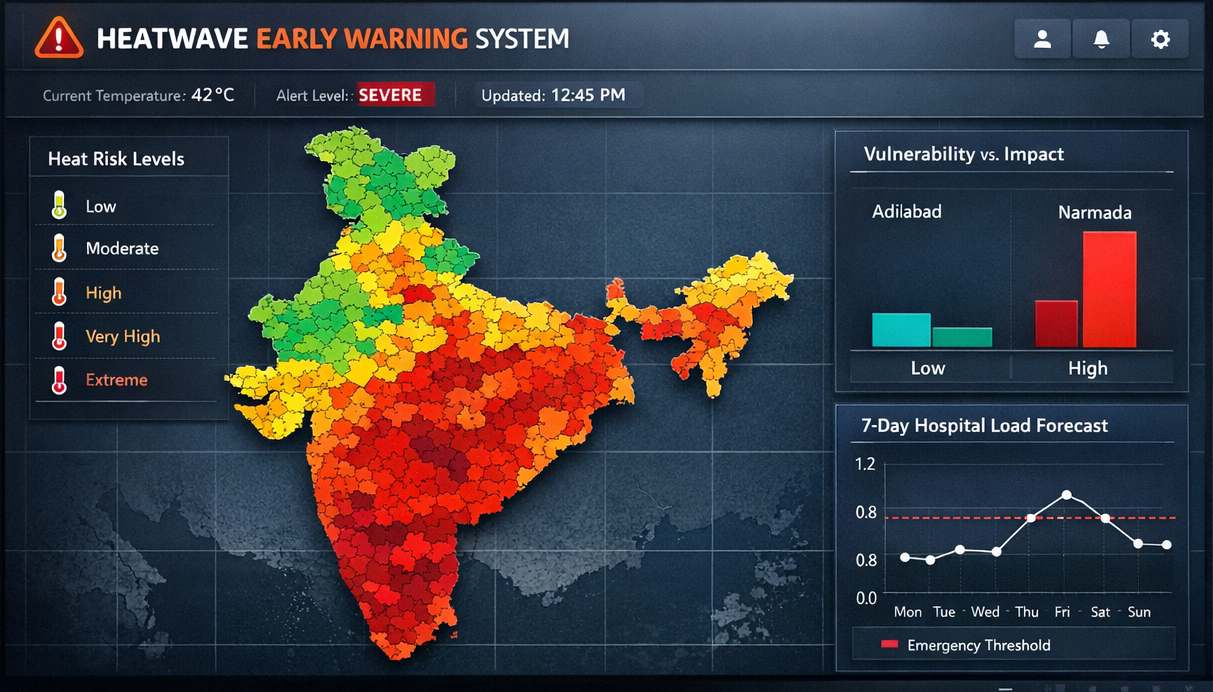